# 07. Deep Learning Models

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data_loader import load_data
from src.splitting import time_train_test_split
from src.evaluation import evaluate, highlight_table
from src.models.dl import dl_forecast, dl_features

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Python version: 3.10.11
Pandas version: 2.1.4
NumPy version: 1.26.4


In [2]:
# Load data using custom loader
try:
    df = load_data('data/processed/data_cleaned.parquet')
    print("Data loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Time span: {df.index.min()} → {df.index.max()}")
    if not df.index.freq:
        df = df.asfreq("1H")
    print(f"Frequency: {df.index.freq}")
except Exception as e:
    print(f"[Error] {e}")

Loading: data/processed/data_cleaned.parquet
Data loaded successfully!
Shape: (35064, 371)
Time span: 2011-01-01 00:00:00 → 2014-12-31 23:00:00
Frequency: <Hour>


In [3]:
# Hourly -> Daily
df_total = df[['total_load']].copy()
df_total = df_total.resample('D').sum(min_count=1)

print("New number of observations:", len(df_total))
print("New frequency:", df_total.index.freq)
df_total.head()

New number of observations: 1461
New frequency: <Day>


,total_load
Timestamp,
2011-01-01,1.713244e+06
2011-01-02,2.785336e+06
2011-01-03,2.812268e+06
2011-01-04,2.866966e+06
2011-01-05,2.880437e+06


In [4]:
# Add features
df_features = dl_features(df_total)
df_features.head()

,total_load,month,day_of_week,day_of_year,is_weekend,day_sin,day_cos,month_sin,month_cos,holiday_flag
Timestamp,,,,,,,,,,
2011-01-01,1.713244e+06,1,5,1,1,0.017213,0.999852,0.5,0.866025,1
2011-01-02,2.785336e+06,1,6,2,1,0.034422,0.999407,0.5,0.866025,0
2011-01-03,2.812268e+06,1,0,3,0,0.051620,0.998667,0.5,0.866025,0
2011-01-04,2.866966e+06,1,1,4,0,0.068802,0.997630,0.5,0.866025,0
2011-01-05,2.880437e+06,1,2,5,0,0.085965,0.996298,0.5,0.866025,0


In [5]:
# Split data
train, test = time_train_test_split(df_features, split_date="2014-01-01")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1096, 10)
Test shape: (365, 10)


## 1. GRU 3 features

In [6]:
FEATURES = [
    "total_load",
    "month",
    "day_of_year",
    "day_of_week"
]

train_3_features = train[FEATURES]
test_3_features = test[FEATURES]

print("Train 3 features shape:", train_3_features.shape)
print("Test 3 features shape:", test_3_features.shape)

Train 3 features shape: (1096, 4)
Test 3 features shape: (365, 4)


In [9]:
# GRU 3 features
# window = 30
three_features_30_pred = dl_forecast(train_3_features, test_3_features, window=30)
# window = 90
three_features_90_pred = dl_forecast(train_3_features, test_3_features, window=90)

# Evaluate
three_features_30_metrics = evaluate(test["total_load"], three_features_30_pred)
three_features_90_metrics = evaluate(test["total_load"], three_features_90_pred)

print("GRU 3 features (window=30):", three_features_30_metrics)
print("GRU 3 features (window=90):", three_features_90_metrics)

GRU 3 features (window=30): {'MAE': 289225.31, 'RMSE': 386386.81, 'MAPE': 5.48}
GRU 3 features (window=90): {'MAE': 273498.99, 'RMSE': 367606.79, 'MAPE': 5.18}


## 2. GRU full features

In [10]:
FEATURES = [
    "total_load",
    "day_sin", "day_cos",
    "month_sin", "month_cos",
    "is_weekend",
    "holiday_flag",
]

train_full_features = train[FEATURES]
test_full_features = test[FEATURES]

print("Train full features shape:", train_full_features.shape)
print("Test full features shape:", test_full_features.shape)

Train full features shape: (1096, 7)
Test full features shape: (365, 7)


In [11]:
# GRU full features
# window = 30
full_features_30_pred = dl_forecast(train_full_features, test_full_features, window=30)
# window = 90
full_features_90_pred = dl_forecast(train_full_features, test_full_features, window=90)

# Evaluate
full_features_30_metrics = evaluate(test_full_features["total_load"], full_features_30_pred)
full_features_90_metrics = evaluate(test_full_features["total_load"], full_features_90_pred)

print("GRU full features (window=30):", full_features_30_metrics)
print("GRU full features (window=90):", full_features_90_metrics)

GRU full features (window=30): {'MAE': 223068.25, 'RMSE': 316924.34, 'MAPE': 4.24}
GRU full features (window=90): {'MAE': 261471.12, 'RMSE': 362158.5, 'MAPE': 4.94}


## 3. GRU no features

In [12]:
TARGET = "total_load"
train_target = train[[TARGET]]
test_target = test[[TARGET]]

print("Train target shape:", train_target.shape)
print("Test target shape:", test_target.shape)

Train target shape: (1096, 1)
Test target shape: (365, 1)


In [13]:
# GRU no features
# window = 30
no_features_30_pred = dl_forecast(train_target, test_target, window=30)
# window = 90
no_features_90_pred = dl_forecast(train_target, test_target, window=90)

# Evaluate
no_features_30_metrics = evaluate(test_target, no_features_30_pred)
no_features_90_metrics = evaluate(test_target, no_features_90_pred)

print("GRU no features (window=30):", no_features_30_metrics)
print("GRU no features (window=90):", no_features_90_metrics)

GRU no features (window=30): {'MAE': 584921.56, 'RMSE': 758668.31, 'MAPE': 10.41}
GRU no features (window=90): {'MAE': 393968.45, 'RMSE': 519936.14, 'MAPE': 7.33}


## 4. Compare

In [15]:
three_features_metrics = {
    "Window=30": three_features_30_metrics,
    "Window=90": three_features_90_metrics
}
full_features_metrics = {
    "Window=30": full_features_30_metrics,
    "Window=90": full_features_90_metrics
}
no_features_metrics = {
    "Window=30": no_features_30_metrics,   
    "Window=90": no_features_90_metrics
}
all_metrics = {
    "GRU 3 features": three_features_metrics,
    "GRU Full features": full_features_metrics,
    "GRU No features": no_features_metrics
}

rows = []
for group_name, group in all_metrics.items():
    for model_name, metrics in group.items():
        rows.append({
            "Group": group_name,
            "Model": model_name,
            "MAE": round(metrics["MAE"], 2),
            "RMSE": round(metrics["RMSE"], 2),
            "MAPE (%)": round(metrics["MAPE"], 2)
        })

comparison_df = pd.DataFrame(rows).set_index(["Group", "Model"])
comparison_df.style.apply(highlight_table).format("{:.2f}")

## 5. Preliminary Forecasting Results

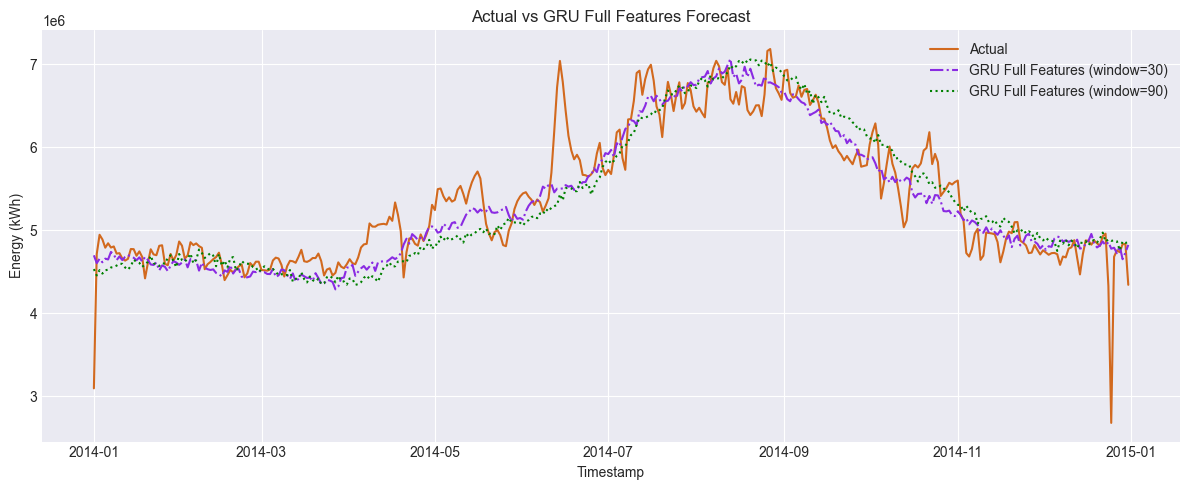

In [19]:
plt.figure(figsize=(12, 5))

full_features_30_pred = pd.Series(
    full_features_30_pred,
    index=test["total_load"].index[-len(full_features_30_pred):]
)

full_features_90_pred = pd.Series(
    full_features_90_pred,
    index=test["total_load"].index[-len(full_features_90_pred):]
)

plt.plot(test["total_load"].index, test["total_load"], label="Actual", color="chocolate")
plt.plot(full_features_30_pred.index, full_features_30_pred, label="GRU Full Features (window=30)", color="blueviolet", linestyle="-.")
plt.plot(full_features_90_pred.index, full_features_90_pred, label="GRU Full Features (window=90)", color="green", linestyle=":")

plt.title("Actual vs GRU Full Features Forecast")
plt.xlabel("Timestamp")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.tight_layout()
plt.show()